# Dependencies of the Timing Residual

This Code produces 5 Figures visualizing the 
1) Mass -
2) Scale -
3) Phase -
4) Measurement length -
5) Pulsar distance -

-dependence of the timing resiudal.

### Setup

In [3]:
import os
os.chdir(os.path.dirname(os.getcwd()))
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter
from src.residual_fct import timing_residual
from src.plotting import axes_plot

### Parameter Definition
These are the parameters given in Table 4.1 of the Thesis in natural units

In [5]:
G = 6.7e-39 #GeV^-2
T = 7.6e21 #GeV^-1
rho = 2.3e-42  #GeV^4
deltaE = 0.1  
deltaP = 0.1  
H = 1.5e-42 #GeV 
a = 1.0
tstart = 0.0

### Reference Values

The reference values are represented by the green lines in the plots.  
Change them here to get similar plots (note that you might have to change the variable ranges in the next cell as well).

In [7]:
k1 = 100/1.56e38 #GeV
theta1 = np.pi/4  
m1 = 1e-33  #GeV
tend1 = 20*4.8e31 #GeV^-1 
chi1 = 2.2*1.56e35 #GeV^-1     

print('m_1 ~ ', np.round(m1*1e9*1e24, 1), 'e-24 eV')
print('theta_1 ~ ', np.round(theta1/np.pi, 2), ' pi')
print('k_1 ~ ', np.round(k1*1.56e38, 1), ' Mpc^-1')
print('tend_1 ~ ', np.round(tend1/(4.8e31), 1), 'yr')
print('chi_1 ~ ', np.round(chi1/(1.56e35), 2), 'kpc')

m_1 ~  1.0 e-24 eV
theta_1 ~  0.25  pi
k_1 ~  100.0  Mpc^-1
tend_1 ~  20.0 yr
chi_1 ~  2.2 kpc


In [8]:
k0 = np.sqrt(12*np.pi*G*rho) #Horizon-Crossing / critical k: 

#variable ranges:
m = np.logspace(-33.5, -31.5, 1500)  #GeV
theta = np.linspace(0.0, np.pi, 100)
k = np.unique(np.r_[np.logspace(np.log10(0.01*H), np.log10(0.01*m1), 100), #GeV #this is k/a not k
                    np.logspace(np.log10(0.7*k0), np.log10(1.3*k0), 80)])  #extra points near k ~ H
tend = np.linspace(1e31, 10**33.7, 150)  #GeV^-1
chi = np.linspace(3.41e35, 3.46e35, 120) #GeV^-1

### Calculation of the Timing Residual

For more details see src/residual_fct

In [10]:
def R(chi, tend, theta, k, m):
    return timing_residual(G, T, rho, deltaE, deltaP, H, a, tstart, tend, m , k, theta, chi) * 6.57e-19 #microsec

res_m = np.array([R(chi1, tend1, theta1, k1, m_) for m_ in m])  
res_k = np.array([R(chi1, tend1, theta1, k_, m1) for k_ in k])  
res_theta = np.array([R(chi1, tend1, theta_, k1, m1) for theta_ in theta]) 
res_tend = np.array([R(chi1, tend_, theta1, k1, m1) for tend_ in tend])  
res_chi = np.array([R(chi_, tend1, theta1, k1, m1) for chi_ in chi])  

### Plotting

Use p_read to adjust the size of axes, ticks, and legend  
Use savefig = 1 if you want to overwrite the figures-file

In [12]:
p_read = 1.5 
savefig = 1  

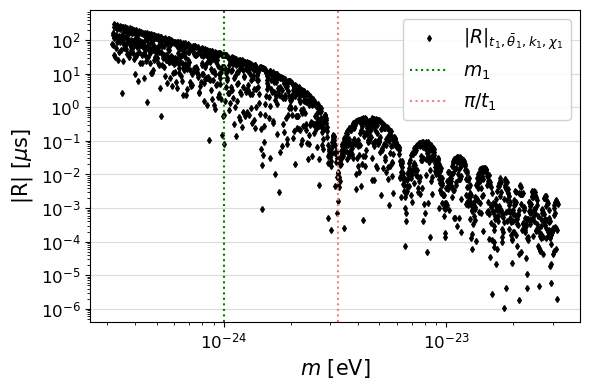

In [13]:
#plot_m_dependence
fig, ax = plt.subplots(figsize=(6, 4)) 
axes_plot(ax, m*1e9, np.abs(res_m), label=r'$|R|_{t_1, \bar\theta_1, k_1, \chi_1}$', xscale='log', yscale='log',  
          xlabel=r'$m$ [eV]', ylabel=r'|R| [$\mu$s]', p_read=p_read)
ax.axvline(m1*1e9, linestyle=':', color='green', label=r'$m_1$')
ax.axvline(np.pi*1e9/tend1, linestyle=':', color='lightcoral', label=r'$\pi/t_1$')
ax.legend(fontsize=9*p_read, framealpha=0.9)
if savefig: plt.savefig('figures/R_m_dependence.png', dpi=300, bbox_inches="tight")
plt.show()

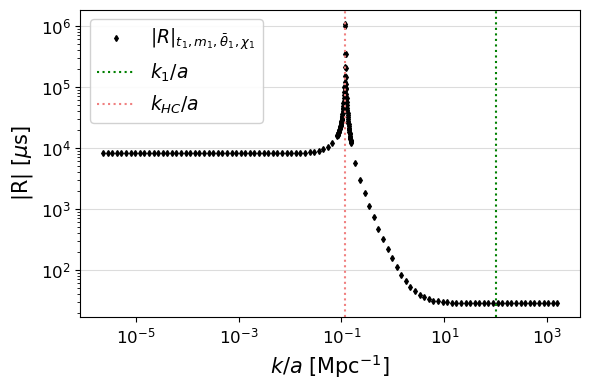

In [14]:
#plot_k_dependence
fig, ax = plt.subplots(figsize=(6, 4)) 
axes_plot(ax, k*1.56e38, np.abs(res_k), label=r'$|R|_{t_1, m_1, \bar\theta_1, \chi_1}$', xscale='log', yscale='log',  
          xlabel=r'$k/a$ [Mpc$^{-1}$]', ylabel=r'|R| [$\mu$s]', p_read=p_read)
ax.axvline(k1*1.56e38, linestyle=':', color='green', label=r'$k_1/a$')
ax.axvline(k0*1.56e38, linestyle=':', color='lightcoral', label=r'$k_{HC}/a$')
ax.legend(fontsize=9*p_read, framealpha=0.9)
if savefig: plt.savefig('figures/R_k_dependence.png', dpi=300, bbox_inches="tight")
plt.show()

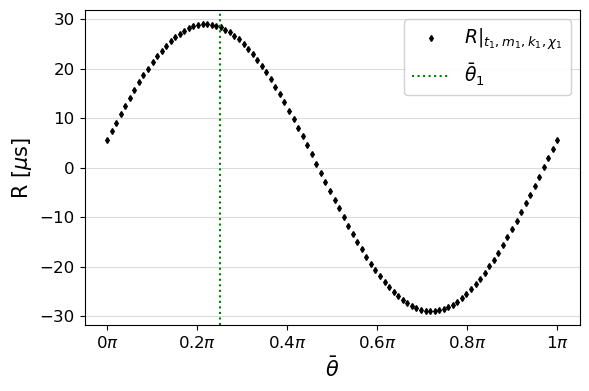

In [15]:
#plot_theta_dependence
fig, ax = plt.subplots(figsize=(6, 4)) 
axes_plot(ax, theta, res_theta, label=r'$R|_{t_1, m_1, k_1, \chi_1}$',   
          xlabel=r'$\bar\theta$', ylabel=r'R [$\mu$s]', p_read=p_read)
ax.axvline(theta1, linestyle=':', color='green', label=r'$\bar\theta_1$')
#change x-axis ticks to multiples of pi/5 
ax.xaxis.set_major_locator(MultipleLocator(np.pi/5))          
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: rf"${x/np.pi:.2g}\pi$"))
ax.legend(fontsize=9*p_read, framealpha=0.9)
if savefig: plt.savefig('figures/R_theta_dependence.png', dpi=300, bbox_inches="tight")
plt.show()

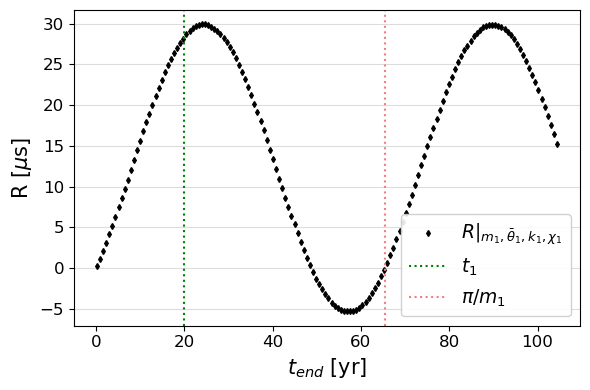

In [16]:
#plot_tend_dependence
fig, ax = plt.subplots(figsize=(6, 4)) 
axes_plot(ax, tend/(4.8e31), res_tend, label=r'$R|_{m_1, \bar\theta_1, k_1, \chi_1}$',   
          xlabel=r'$t_{end}$ [yr]', ylabel=r'R [$\mu$s]', p_read=p_read)
ax.axvline(tend1/(4.8e31), linestyle=':', color='green', label=r'$t_1$')
ax.axvline(np.pi/(m1*4.8e31), linestyle=':',  color='lightcoral', label=r'$\pi/m_1$')
ax.legend(fontsize=9*p_read, framealpha=0.9)
if savefig: plt.savefig('figures/R_tend_dependence.png', dpi=300, bbox_inches="tight")
plt.show()

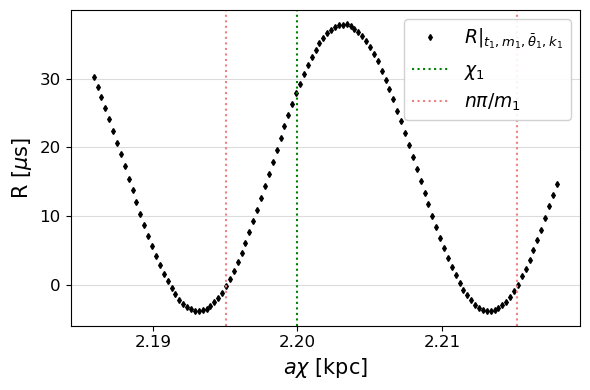

In [17]:
#plot_chi_dependence
fig, ax = plt.subplots(figsize=(6, 4)) 
axes_plot(ax, a*chi/(1.56e35), res_chi, label=r'$R|_{t_1, m_1, \bar\theta_1, k_1}$',   
          xlabel=r'$a\chi$ [kpc]', ylabel=r'R [$\mu$s]', p_read=p_read)
ax.axvline(a*chi1/(1.56e35), linestyle=':', color='green', label=r'$\chi_1$')
#a*m*chi = n*pi
n_chi = np.round(a*m1*chi1/np.pi, 0)
ax.axvline(n_chi*np.pi/(m1*1.56e35), linestyle=':',  color='lightcoral', label=r'$n\pi/m_1$')
ax.axvline((n_chi+1)*np.pi/(m1*1.56e35), linestyle=':',  color='lightcoral', label=None)
ax.legend(fontsize=9*p_read, framealpha=0.9)
#change x-axis ticks 
ax.xaxis.set_major_locator(MultipleLocator(0.01))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.2f}"))
ax.legend(fontsize=9*p_read, framealpha=0.9)
if savefig: plt.savefig('figures/R_chi_dependence.png', dpi=300, bbox_inches="tight")
plt.show()